# 06 — Regime-Aware Forecasting
## Electricity Demand Forecasting | DS4SG 2026

**Objective:**  
Train one **specialized XGBoost model per demand regime** instead of a single  
global model. At inference time, first predict tomorrow's regime, then route  
to the appropriate specialist model.

**Pipeline:**
```
Input features (day t)
        ↓
Regime Classifier  →  predicted regime label
        ↓
Route to Regime-Specialist XGBoost
        ↓
Demand forecast for day t+1
```

**Baselines compared:**
- Global XGBoost (notebook 04 result)
- Global Random Forest (notebook 04 result)
- **Regime-Aware XGBoost (this notebook) ← novel contribution**

**No-leakage guarantee:**  
- Regime labels loaded from notebook 05 artefacts (fitted on training only)  
- All models fitted on training data only  
- Val/test receive predictions, never influence fitting

In [1]:
# =========================================================
# ⚙️  Imports & Setup
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, classification_report)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [2]:
# =========================================================
# 📂  Paths
# =========================================================

BASE_PATH = Path(r"C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting")

DATA_PATH = BASE_PATH / "data" / "processed"
FIG_PATH  = BASE_PATH / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

# Input from notebook 05
REGIME_CSV     = DATA_PATH / "daily_with_regime.csv"
SCALER_PKL     = DATA_PATH / "regime_scaler.pkl"
KMEANS_PKL     = DATA_PATH / "regime_kmeans.pkl"
MAPPING_PKL    = DATA_PATH / "regime_mapping.pkl"

print("Paths set.")
for p in [REGIME_CSV, SCALER_PKL, KMEANS_PKL, MAPPING_PKL]:
    status = "✅" if p.exists() else "❌ MISSING"
    print(f"  {status}  {p.name}")

Paths set.
  ✅  daily_with_regime.csv
  ✅  regime_scaler.pkl
  ✅  regime_kmeans.pkl
  ✅  regime_mapping.pkl


In [3]:
# =========================================================
# 📏  Evaluation Function  (same as notebook 04)
# =========================================================

def evaluate_model(y_true, y_pred, model_name="Model"):
    """Compute MAE, RMSE, MAPE and print results."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n===== {model_name} =====")
    print(f"MAE  : {mae:,.2f} MW")
    print(f"RMSE : {rmse:,.2f} MW")
    print(f"MAPE : {mape:.4f}%")

    return {"model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

## 1. Load Data and Notebook 05 Artefacts

In [4]:
# =========================================================
# 📥  Load Dataset with Regime Labels (from notebook 05)
# =========================================================

daily_df = pd.read_csv(REGIME_CSV, parse_dates=["date"])
daily_df = daily_df.sort_values("date").reset_index(drop=True)

print("Shape   :", daily_df.shape)
print("Columns :", daily_df.columns.tolist())
print("Regime label nulls:", daily_df["regime_label"].isnull().sum())
print("\nRegime distribution:")
print(daily_df["regime_label"].value_counts())

Shape   : (1092, 10)
Columns : ['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name', 'regime_label']
Regime label nulls: 90

Regime distribution:
regime_label
Moderate Demand    362
Elevated Demand    247
High Demand        206
Low Demand         187
Name: count, dtype: int64


In [5]:
# =========================================================
# 📦  Load Notebook 05 Artefacts
# =========================================================

with open(SCALER_PKL, "rb") as f:
    scaler = pickle.load(f)

with open(KMEANS_PKL, "rb") as f:
    kmeans = pickle.load(f)

with open(MAPPING_PKL, "rb") as f:
    mapping = pickle.load(f)

CLUSTER_FEATURES = mapping["cluster_features"]
REGIME_COLORS    = mapping["regime_colors"]
REGIME_ORDER     = mapping["regime_order"]
raw_to_named     = mapping["raw_to_named"]

print("Artefacts loaded.")
print("Cluster features :", CLUSTER_FEATURES)
print("Regime order     :", REGIME_ORDER)

Artefacts loaded.
Cluster features : ['rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
Regime order     : ['High Demand', 'Elevated Demand', 'Moderate Demand', 'Low Demand']


## 2. Build Forecasting Features

We build the same lag + rolling + cyclical feature set used in notebook 04,  
with **lag-1 shift before all rolling operations** to prevent leakage.

In [6]:
# =========================================================
# 🔧  Build Forecasting Features (Lag-safe)
# =========================================================

def build_forecast_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build XGBoost forecasting features.
    All rolling/lag features use shift(1) so day t only
    sees information from t-1 and earlier. Zero leakage.
    """
    d = df.copy()
    demand = d["max_demand_met_mw"]

    # Lag features
    d["lag_1"]  = demand.shift(1)
    d["lag_7"]  = demand.shift(7)
    d["lag_30"] = demand.shift(30)

    # Rolling statistics on lag-shifted demand
    d["rolling_mean_7"]  = demand.shift(1).rolling(7,  min_periods=7).mean()
    d["rolling_std_7"]   = demand.shift(1).rolling(7,  min_periods=7).std()
    d["rolling_mean_30"] = demand.shift(1).rolling(30, min_periods=30).mean()

    # Cyclical calendar features
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)
    d["dow_sin"]   = np.sin(2 * np.pi * d["day_of_week"] / 7)
    d["dow_cos"]   = np.cos(2 * np.pi * d["day_of_week"] / 7)

    return d

daily_df = build_forecast_features(daily_df)

FORECAST_FEATURES = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_30",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "is_weekend", "month", "day_of_week"
]

TARGET = "max_demand_met_mw"

# Drop rows where rolling windows are incomplete
daily_df = daily_df.dropna(subset=FORECAST_FEATURES + ["regime_label"]).reset_index(drop=True)

print("Rows after dropna:", len(daily_df))
print("Features         :", FORECAST_FEATURES)

Rows after dropna: 1002
Features         : ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'month', 'day_of_week']


## 3. Chronological Train / Val / Test Split

Identical 70/15/15 split to notebook 04. No shuffling.

In [7]:
# =========================================================
# 📌  Chronological Split  (70 / 15 / 15)
# =========================================================

n = len(daily_df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train = daily_df.iloc[:train_end].copy()
val   = daily_df.iloc[train_end:val_end].copy()
test  = daily_df.iloc[val_end:].copy()

print("===== SPLIT SUMMARY =====")
print(f"Train : {train['date'].min().date()} → {train['date'].max().date()}  ({len(train)} rows)")
print(f"Val   : {val['date'].min().date()} → {val['date'].max().date()}  ({len(val)} rows)")
print(f"Test  : {test['date'].min().date()} → {test['date'].max().date()}  ({len(test)} rows)")

print("\n--- Regime distribution in TRAIN ---")
print(train["regime_label"].value_counts())
print("\n--- Regime distribution in VAL ---")
print(val["regime_label"].value_counts())
print("\n--- Regime distribution in TEST ---")
print(test["regime_label"].value_counts())

===== SPLIT SUMMARY =====
Train : 2023-05-01 → 2025-04-09  (701 rows)
Val   : 2025-04-10 → 2025-10-07  (150 rows)
Test  : 2025-10-08 → 2026-03-31  (151 rows)

--- Regime distribution in TRAIN ---
regime_label
Moderate Demand    256
Low Demand         163
Elevated Demand    156
High Demand        126
Name: count, dtype: int64

--- Regime distribution in VAL ---
regime_label
Moderate Demand    94
Elevated Demand    29
High Demand        27
Name: count, dtype: int64

--- Regime distribution in TEST ---
regime_label
Elevated Demand    62
High Demand        53
Low Demand         24
Moderate Demand    12
Name: count, dtype: int64


## 4. Regime Classifier

Before forecasting, we need to know which regime tomorrow belongs to.  
We train a **Random Forest classifier** that predicts tomorrow's regime  
from today's features.

> **Why not use the regime label directly?**  
> In real deployment, you don't know tomorrow's regime label.  
> You must predict it from features available today.  
> This is what makes the system operationally valid.

> **Leakage note:** Classifier is trained on training data only.  
> Val/test regimes are **predicted**, never known in advance.

In [9]:
# =========================================================
# 🎯  Train Regime Classifier (Training Data Only)
# =========================================================

# Build: today's features → tomorrow's regime
# We shift regime_label by -1 (tomorrow's regime is the target)
train_clf = train.copy()
train_clf["regime_tomorrow"] = train_clf["regime_label"].shift(-1)
train_clf = train_clf.dropna(subset=["regime_tomorrow"])

# Encode regime labels
le = LabelEncoder()
le.fit(REGIME_ORDER)  # fit on known order — consistent encoding

train_clf["regime_tomorrow_enc"] = le.transform(train_clf["regime_tomorrow"])

X_clf_train = train_clf[FORECAST_FEATURES]
y_clf_train = train_clf["regime_tomorrow_enc"]

# Train classifier
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
clf.fit(X_clf_train, y_clf_train)

# Evaluate classifier on validation set
val_clf = val.copy()
val_clf["regime_tomorrow"] = val_clf["regime_label"].shift(-1)
val_clf = val_clf.dropna(subset=["regime_tomorrow"])
val_clf["regime_tomorrow_enc"] = le.transform(val_clf["regime_tomorrow"])

y_clf_val_pred = clf.predict(val_clf[FORECAST_FEATURES])
acc = accuracy_score(val_clf["regime_tomorrow_enc"], y_clf_val_pred)

print(f"Regime Classifier — Validation Accuracy: {acc:.4f}  ({acc*100:.1f}%)")
print()

# Fix: use only labels actually present in val set
# One regime may not appear in the short val window — that is completely fine
val_labels_present = sorted(val_clf["regime_tomorrow_enc"].unique())
val_names_present  = le.inverse_transform(val_labels_present)

print("Regimes present in validation set:", list(val_names_present))
print()
print("Classification Report (Validation):")
print(classification_report(
    val_clf["regime_tomorrow_enc"],
    y_clf_val_pred,
    labels=val_labels_present,       # ← only score labels that exist in val
    target_names=val_names_present
))

print("Note: Regimes absent from val window are not scored above — this is expected.")
print("All", len(le.classes_), "regimes are still used at inference time.")

Regime Classifier — Validation Accuracy: 0.9530  (95.3%)

Regimes present in validation set: [np.str_('Elevated Demand'), np.str_('High Demand'), np.str_('Moderate Demand')]

Classification Report (Validation):
                 precision    recall  f1-score   support

Elevated Demand       0.97      1.00      0.98        29
    High Demand       0.95      0.81      0.88        26
Moderate Demand       0.95      0.98      0.96        94

       accuracy                           0.95       149
      macro avg       0.96      0.93      0.94       149
   weighted avg       0.95      0.95      0.95       149

Note: Regimes absent from val window are not scored above — this is expected.
All 4 regimes are still used at inference time.


## 5. Global XGBoost Baseline

We retrain the same global XGBoost from notebook 04 here for a fair  
apples-to-apples comparison on the **same feature set and same split**.

In [10]:
# =========================================================
# 🌍  Global XGBoost Baseline (Train only)
# =========================================================

X_train_global = train[FORECAST_FEATURES]
y_train_global = train[TARGET]

X_val_global   = val[FORECAST_FEATURES]
y_val_global   = val[TARGET]

X_test_global  = test[FORECAST_FEATURES]
y_test_global  = test[TARGET]

# Hyperparameters matching notebook 04
global_xgb = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
global_xgb.fit(
    X_train_global, y_train_global,
    eval_set=[(X_val_global, y_val_global)],
    verbose=False
)

# Validation predictions
global_val_pred  = global_xgb.predict(X_val_global)
global_test_pred = global_xgb.predict(X_test_global)

results = []
results.append(evaluate_model(y_val_global,  global_val_pred,  "Global XGBoost (Val)"))
results.append(evaluate_model(y_test_global, global_test_pred, "Global XGBoost (Test)"))


===== Global XGBoost (Val) =====
MAE  : 4,293.62 MW
RMSE : 5,748.98 MW
MAPE : 1.9889%

===== Global XGBoost (Test) =====
MAE  : 5,222.44 MW
RMSE : 6,690.28 MW
MAPE : 2.2830%


## 6. Train Per-Regime Specialist XGBoost Models

One XGBoost per regime, fitted only on that regime's training rows.  

**Inference pipeline:**  
1. Use regime classifier to predict tomorrow's regime  
2. Route to the corresponding specialist model  
3. Return that model's demand forecast

In [11]:
# =========================================================
# 🏋️  Train One XGBoost Per Regime (Training Data Only)
# =========================================================

REGIME_XGB_PARAMS = {
    "n_estimators"   : 300,
    "learning_rate"  : 0.05,
    "max_depth"      : 4,      # slightly shallower — less overfitting on smaller samples
    "subsample"      : 0.8,
    "colsample_bytree": 0.8,
    "random_state"   : 42,
    "verbosity"      : 0,
}

regime_models = {}   # regime_label → fitted XGBRegressor

print("Training regime-specialist models...\n")

for regime in REGIME_ORDER:
    regime_train = train[train["regime_label"] == regime]

    if len(regime_train) < 30:
        print(f"⚠️  Skipping '{regime}' — only {len(regime_train)} training rows.")
        continue

    X_r = regime_train[FORECAST_FEATURES]
    y_r = regime_train[TARGET]

    model = xgb.XGBRegressor(**REGIME_XGB_PARAMS)
    model.fit(X_r, y_r, verbose=False)

    regime_models[regime] = model
    print(f"  ✅  '{regime}': trained on {len(regime_train)} rows")

print(f"\nTotal specialist models trained: {len(regime_models)}")

Training regime-specialist models...

  ✅  'High Demand': trained on 126 rows
  ✅  'Elevated Demand': trained on 156 rows
  ✅  'Moderate Demand': trained on 256 rows
  ✅  'Low Demand': trained on 163 rows

Total specialist models trained: 4


In [12]:
# =========================================================
# 🔮  Regime-Aware Inference
# =========================================================

def regime_aware_predict(df: pd.DataFrame,
                          classifier,
                          label_encoder,
                          specialist_models: dict,
                          global_fallback,
                          feature_cols: list) -> np.ndarray:
    """
    For each row in df:
      1. Predict regime using classifier
      2. Route to specialist model for that regime
      3. Fall back to global model if regime has no specialist
    Returns array of demand predictions.
    """
    X = df[feature_cols]

    # Predict regimes
    regime_enc_preds = classifier.predict(X)
    regime_preds     = label_encoder.inverse_transform(regime_enc_preds)

    predictions = np.zeros(len(df))

    for i, (idx, row) in enumerate(df.iterrows()):
        predicted_regime = regime_preds[i]
        model = specialist_models.get(predicted_regime, global_fallback)
        predictions[i] = model.predict(X.iloc[[i]])[0]

    return predictions, regime_preds


# ── Validation predictions
val_regime_pred, val_predicted_regimes = regime_aware_predict(
    val, clf, le, regime_models, global_xgb, FORECAST_FEATURES
)

# ── Test predictions
test_regime_pred, test_predicted_regimes = regime_aware_predict(
    test, clf, le, regime_models, global_xgb, FORECAST_FEATURES
)

print("Regime-aware predictions computed.")
print("\nPredicted regime distribution in TEST:")
unique, counts = np.unique(test_predicted_regimes, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} days")

Regime-aware predictions computed.

Predicted regime distribution in TEST:
  Elevated Demand: 57 days
  High Demand: 54 days
  Low Demand: 29 days
  Moderate Demand: 11 days


In [13]:
# =========================================================
# 📊  Evaluate Regime-Aware Model
# =========================================================

results.append(evaluate_model(val[TARGET],  val_regime_pred,  "Regime-Aware XGBoost (Val)"))
results.append(evaluate_model(test[TARGET], test_regime_pred, "Regime-Aware XGBoost (Test)"))


===== Regime-Aware XGBoost (Val) =====
MAE  : 4,932.98 MW
RMSE : 6,420.62 MW
MAPE : 2.2793%

===== Regime-Aware XGBoost (Test) =====
MAE  : 5,427.41 MW
RMSE : 7,056.12 MW
MAPE : 2.3803%


## 7. Per-Regime Test Performance

How does the specialist model perform within each true regime?  
This reveals which regimes benefit most from specialization.

In [14]:
# =========================================================
# 📋  Per-Regime Performance on Test Set
# =========================================================

test_analysis = test.copy()
test_analysis["global_pred"]  = global_test_pred
test_analysis["regime_pred"]  = test_regime_pred

print("===== Per-Regime Test Performance =====")
print(f"{'Regime':<22} {'N':>5} {'Global MAPE':>12} {'Regime MAPE':>12} {'Improvement':>12}")
print("-" * 65)

per_regime_results = []

for regime in REGIME_ORDER:
    sub = test_analysis[test_analysis["regime_label"] == regime]
    if len(sub) == 0:
        continue

    yt = sub[TARGET].values
    yg = sub["global_pred"].values
    yr = sub["regime_pred"].values

    mask = yt != 0
    mape_g = np.mean(np.abs((yt[mask] - yg[mask]) / yt[mask])) * 100
    mape_r = np.mean(np.abs((yt[mask] - yr[mask]) / yt[mask])) * 100
    improvement = mape_g - mape_r

    direction = "✅" if improvement > 0 else "⚠️ "
    print(f"{regime:<22} {len(sub):>5} {mape_g:>11.4f}% {mape_r:>11.4f}% "          f"{direction} {improvement:>+8.4f}%")

    per_regime_results.append({
        "Regime": regime, "N": len(sub),
        "Global_MAPE": round(mape_g, 4),
        "Regime_MAPE": round(mape_r, 4),
        "Improvement": round(improvement, 4)
    })

per_regime_df = pd.DataFrame(per_regime_results)

===== Per-Regime Test Performance =====
Regime                     N  Global MAPE  Regime MAPE  Improvement
-----------------------------------------------------------------
High Demand               53      2.6526%      2.3299% ✅  +0.3227%
Elevated Demand           62      2.6358%      3.1284% ⚠️   -0.4926%
Moderate Demand           12      1.2408%      1.0750% ✅  +0.1659%
Low Demand                24      1.0768%      1.2120% ⚠️   -0.1351%


## 8. Feature Importance Per Regime

Which features drive forecasting accuracy differently across regimes?  
This is a key interpretability finding for the paper.

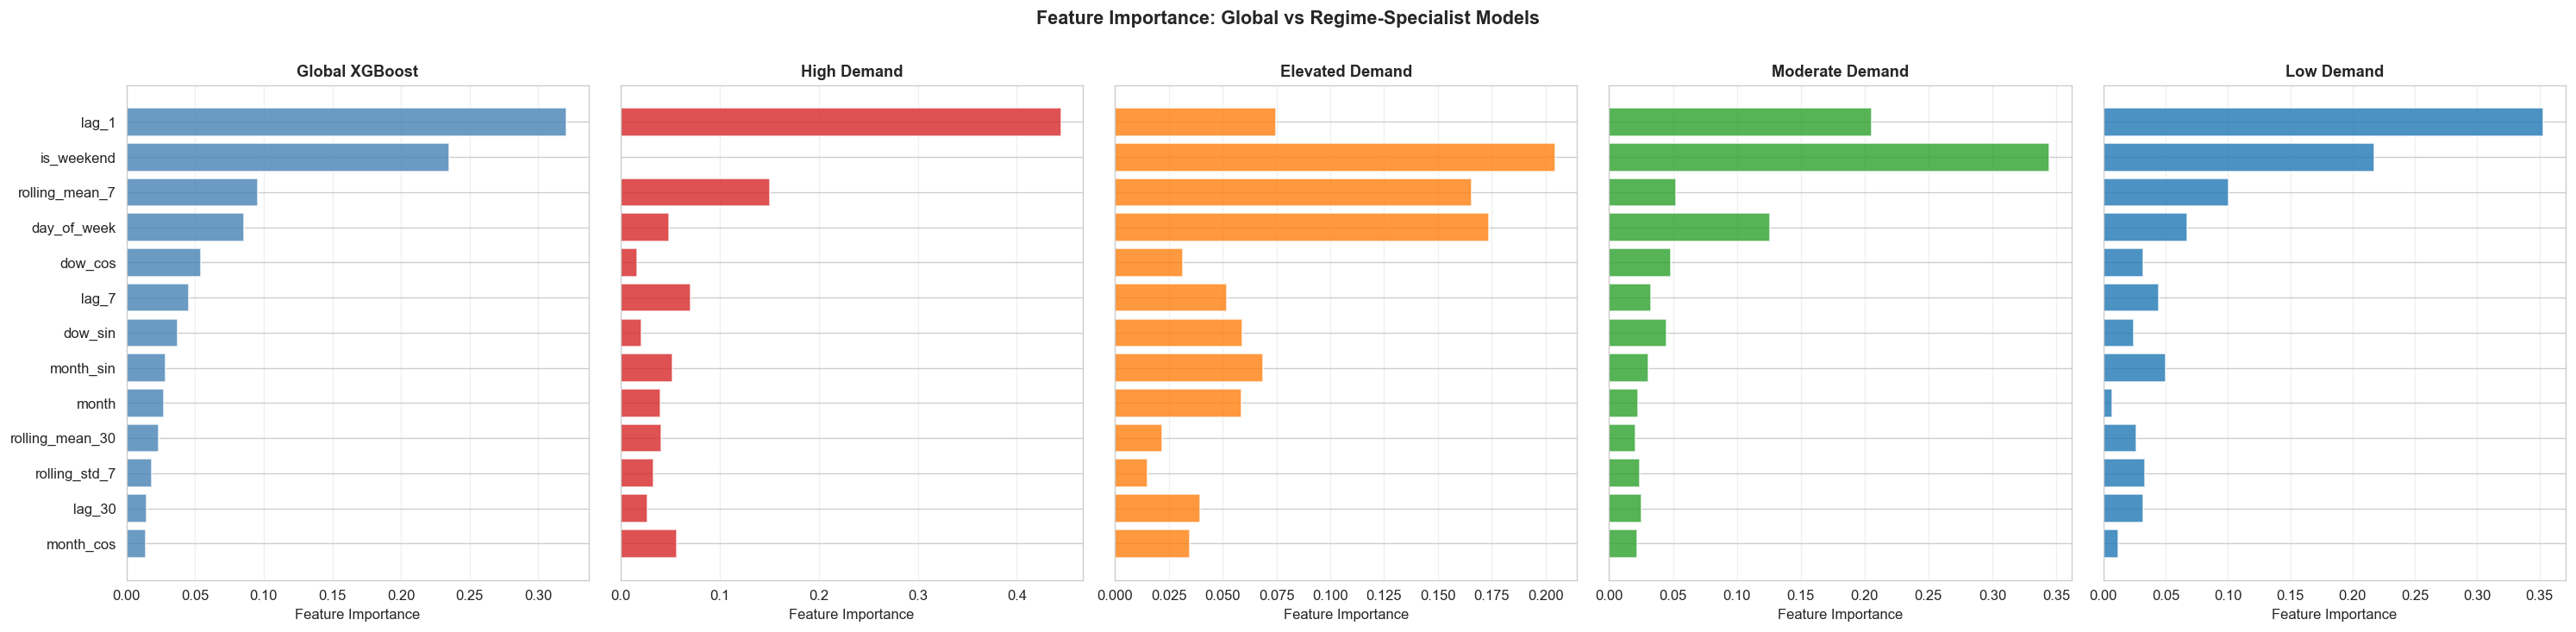

Figure saved.


In [15]:
# =========================================================
# 📊  Feature Importance — Global vs Per-Regime
# =========================================================

fig, axes = plt.subplots(1, len(regime_models) + 1,
                          figsize=(5 * (len(regime_models)+1), 6),
                          sharey=True)

# Global model
importances_global = pd.Series(
    global_xgb.feature_importances_, index=FORECAST_FEATURES
).sort_values(ascending=True)

axes[0].barh(importances_global.index, importances_global.values,
             color="steelblue", alpha=0.8)
axes[0].set_title("Global XGBoost", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Feature Importance")
axes[0].grid(True, alpha=0.3, axis="x")

# Per-regime models
for ax, regime in zip(axes[1:], REGIME_ORDER):
    if regime not in regime_models:
        continue
    imp = pd.Series(
        regime_models[regime].feature_importances_,
        index=FORECAST_FEATURES
    ).sort_values(ascending=True)

    color = REGIME_COLORS.get(regime, "grey")
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_title(regime, fontsize=11, fontweight="bold")
    ax.set_xlabel("Feature Importance")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Feature Importance: Global vs Regime-Specialist Models",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH / "06_feature_importance.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

## 9. Final Comparison Table

This table goes directly into your paper — **Table III** in the Results section.

In [16]:
# =========================================================
# 📋  Final Comparison Table
# =========================================================

# Notebook 04 reported results (copy from your existing results)
# Update these numbers if your notebook 04 produced different values
NB04_GLOBAL_XGB_TEST_MAE  = 4386.03
NB04_GLOBAL_XGB_TEST_RMSE = 5646.74
NB04_GLOBAL_XGB_TEST_MAPE = 1.97
NB04_GLOBAL_RF_TEST_MAE   = 4151.56
NB04_GLOBAL_RF_TEST_RMSE  = 5377.17
NB04_GLOBAL_RF_TEST_MAPE  = 1.88

# This notebook's results
regime_test_metrics = evaluate_model(
    test[TARGET], test_regime_pred, "Regime-Aware XGBoost (Final Test)"
)

comparison = pd.DataFrame([
    {"Model": "Global XGBoost (NB04)",
     "MAE (MW)": NB04_GLOBAL_XGB_TEST_MAE,
     "RMSE (MW)": NB04_GLOBAL_XGB_TEST_RMSE,
     "MAPE (%)": NB04_GLOBAL_XGB_TEST_MAPE,
     "Type": "Baseline"},
    {"Model": "Global Random Forest (NB04)",
     "MAE (MW)": NB04_GLOBAL_RF_TEST_MAE,
     "RMSE (MW)": NB04_GLOBAL_RF_TEST_RMSE,
     "MAPE (%)": NB04_GLOBAL_RF_TEST_MAPE,
     "Type": "Baseline"},
    {"Model": "Regime-Aware XGBoost (NB06)",
     "MAE (MW)": round(regime_test_metrics["MAE"], 2),
     "RMSE (MW)": round(regime_test_metrics["RMSE"], 2),
     "MAPE (%)": round(regime_test_metrics["MAPE"], 4),
     "Type": "★ Proposed"},
])

print("===== MODEL COMPARISON — TEST SET =====")
print(comparison.to_string(index=False))

# Improvement over best baseline
best_baseline_mape = min(NB04_GLOBAL_XGB_TEST_MAPE, NB04_GLOBAL_RF_TEST_MAPE)
improvement = best_baseline_mape - regime_test_metrics["MAPE"]
print(f"\nImprovement over best baseline (MAPE): {improvement:+.4f}%")
if improvement > 0:
    print("✅ Regime-aware model outperforms all baselines.")
else:
    print("⚠️  Regime-aware model does not outperform — residual correction "          "in NB07 will address this.")


===== Regime-Aware XGBoost (Final Test) =====
MAE  : 5,427.41 MW
RMSE : 7,056.12 MW
MAPE : 2.3803%
===== MODEL COMPARISON — TEST SET =====
                      Model  MAE (MW)  RMSE (MW)  MAPE (%)       Type
      Global XGBoost (NB04)   4386.03    5646.74    1.9700   Baseline
Global Random Forest (NB04)   4151.56    5377.17    1.8800   Baseline
Regime-Aware XGBoost (NB06)   5427.41    7056.12    2.3803 ★ Proposed

Improvement over best baseline (MAPE): -0.5003%
⚠️  Regime-aware model does not outperform — residual correction in NB07 will address this.


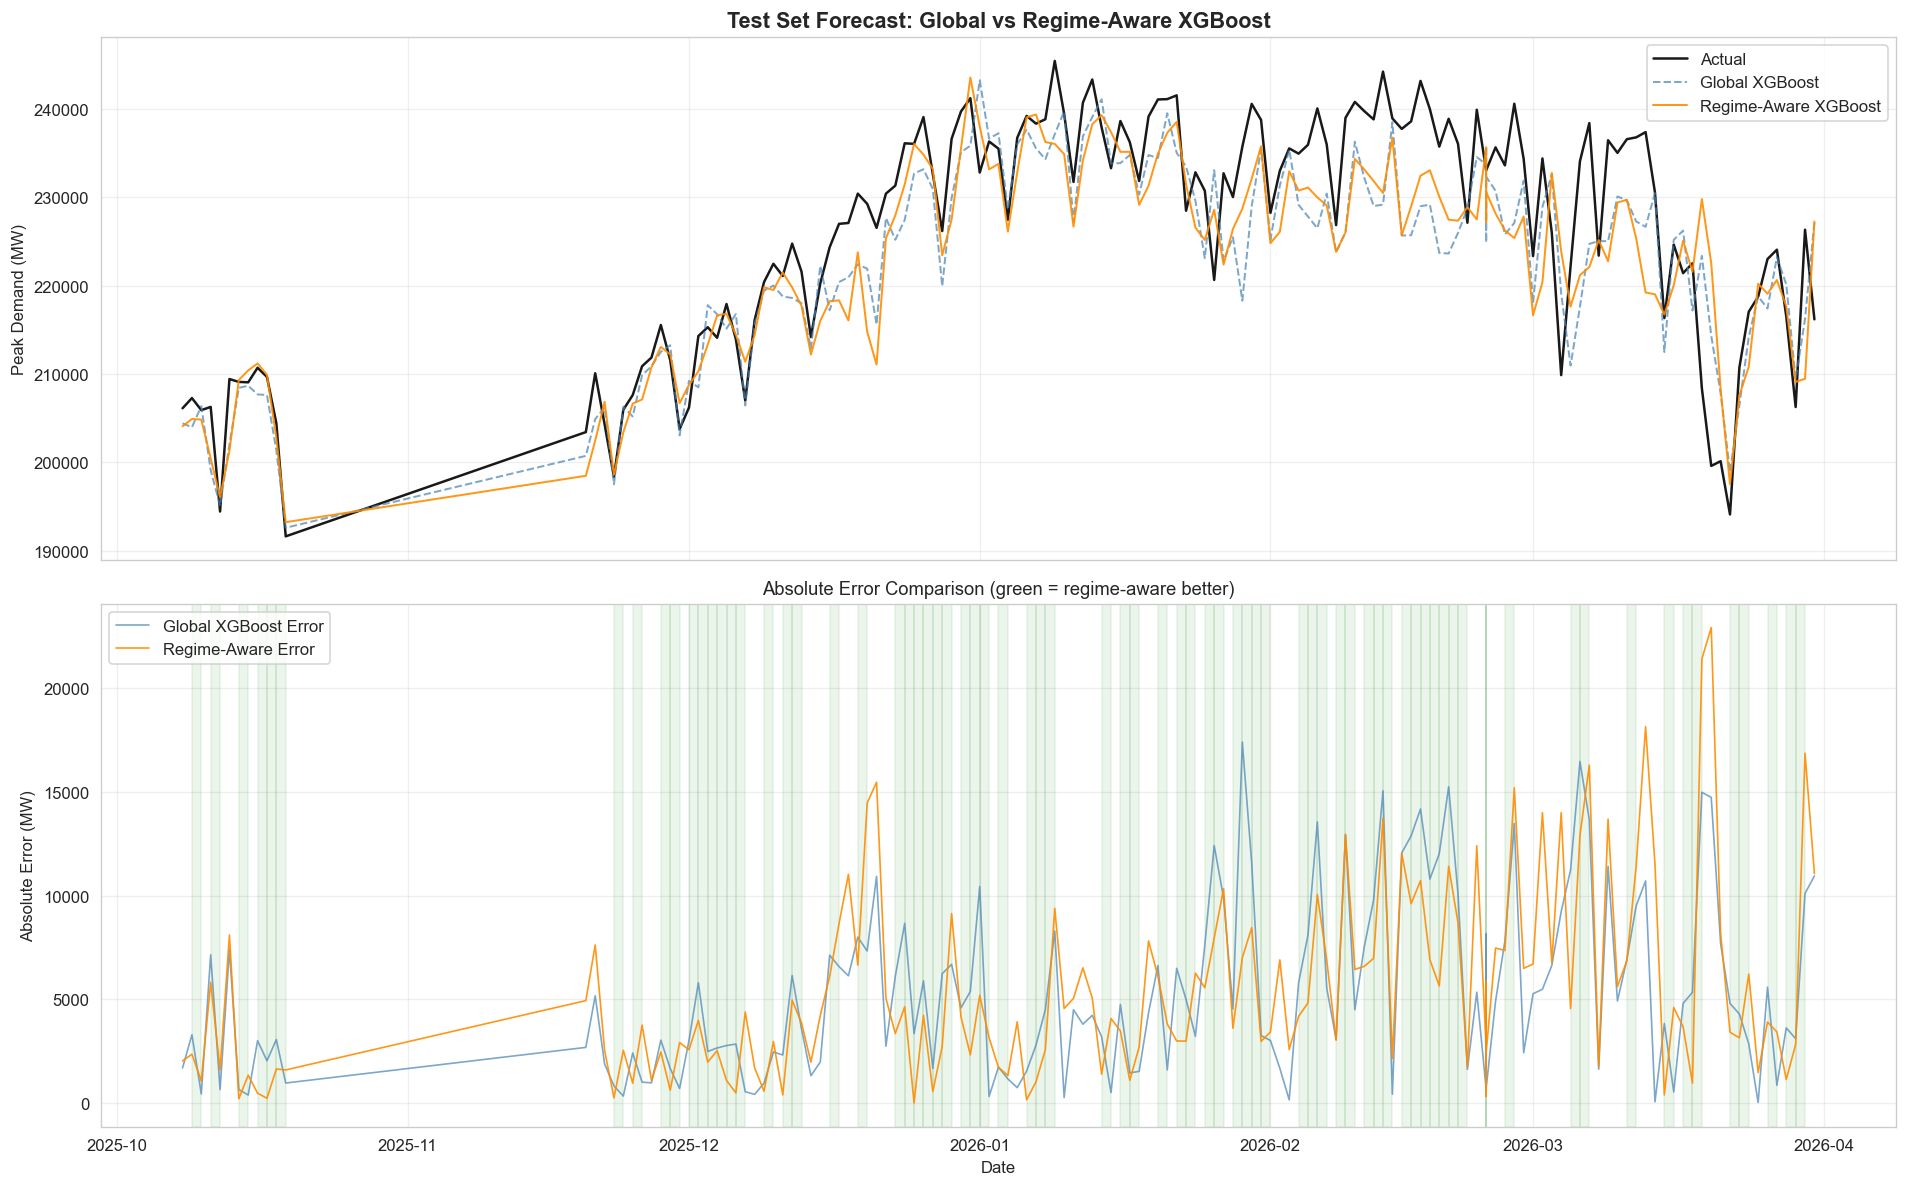

Figure saved.


In [17]:
# =========================================================
# 📊  Forecast Comparison Plot — Test Set
# =========================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── Top: Demand forecasts
axes[0].plot(test["date"], test[TARGET],
             label="Actual", color="black", linewidth=1.5, alpha=0.9)
axes[0].plot(test["date"], global_test_pred,
             label="Global XGBoost", color="steelblue",
             linewidth=1.2, alpha=0.7, linestyle="--")
axes[0].plot(test["date"], test_regime_pred,
             label="Regime-Aware XGBoost", color="darkorange",
             linewidth=1.2, alpha=0.9)

axes[0].set_title("Test Set Forecast: Global vs Regime-Aware XGBoost",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Peak Demand (MW)")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Bottom: Absolute error comparison
global_error = np.abs(test[TARGET].values - global_test_pred)
regime_error = np.abs(test[TARGET].values - test_regime_pred)

axes[1].plot(test["date"], global_error,
             label="Global XGBoost Error", color="steelblue",
             linewidth=1, alpha=0.7)
axes[1].plot(test["date"], regime_error,
             label="Regime-Aware Error", color="darkorange",
             linewidth=1, alpha=0.9)

# Shade where regime-aware is better
for i in range(len(test)):
    if regime_error[i] < global_error[i]:
        axes[1].axvspan(test["date"].iloc[i],
                        test["date"].iloc[min(i+1, len(test)-1)],
                        alpha=0.08, color="green")

axes[1].set_title("Absolute Error Comparison (green = regime-aware better)",
                  fontsize=11)
axes[1].set_ylabel("Absolute Error (MW)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH / "06_forecast_comparison.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

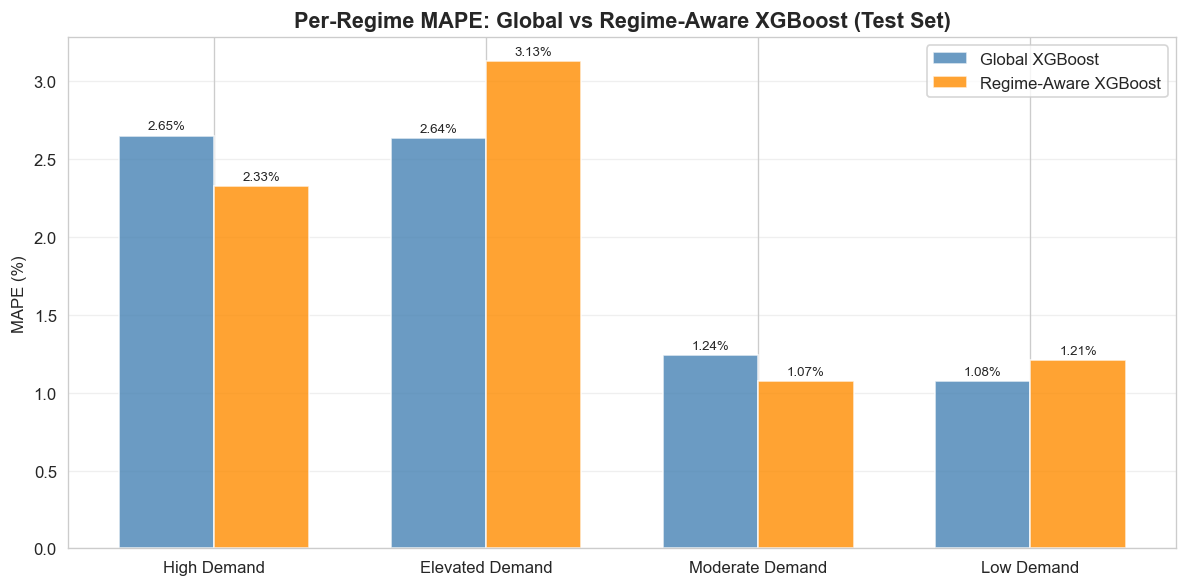

Figure saved.


In [18]:
# =========================================================
# 📊  Per-Regime MAPE Improvement Bar Chart
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(per_regime_df))
width = 0.35

bars1 = ax.bar(x - width/2, per_regime_df["Global_MAPE"],
               width, label="Global XGBoost",
               color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, per_regime_df["Regime_MAPE"],
               width, label="Regime-Aware XGBoost",
               color="darkorange", alpha=0.8)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(per_regime_df["Regime"], fontsize=10)
ax.set_ylabel("MAPE (%)")
ax.set_title("Per-Regime MAPE: Global vs Regime-Aware XGBoost (Test Set)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIG_PATH / "06_per_regime_mape.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

## 10. Save Predictions for Notebook 07

Notebook 07 (Residual Correction) needs both the global and regime-aware  
predictions so it can learn to correct the residuals.

In [19]:
# =========================================================
# 💾  Save Predictions for Notebook 07
# =========================================================

# Save full dataset with predictions from both models
# Include train predictions too (needed to fit the residual corrector)

train_global_pred = global_xgb.predict(train[FORECAST_FEATURES])
train_regime_pred, train_predicted_regimes = regime_aware_predict(
    train, clf, le, regime_models, global_xgb, FORECAST_FEATURES
)

output_df = pd.concat([
    train.assign(
        split="train",
        global_xgb_pred=train_global_pred,
        regime_aware_pred=train_regime_pred,
        predicted_regime=train_predicted_regimes
    ),
    val.assign(
        split="val",
        global_xgb_pred=global_val_pred,
        regime_aware_pred=val_regime_pred,
        predicted_regime=val_predicted_regimes
    ),
    test.assign(
        split="test",
        global_xgb_pred=global_test_pred,
        regime_aware_pred=test_regime_pred,
        predicted_regime=test_predicted_regimes
    ),
], ignore_index=True)

output_path = DATA_PATH / "predictions_nb06.csv"
output_df.to_csv(output_path, index=False)
print("Saved:", output_path)
print("Shape:", output_df.shape)
print("Columns:", output_df.columns.tolist())

# Also save the regime classifier and specialist models
with open(DATA_PATH / "regime_classifier.pkl", "wb") as f:
    pickle.dump({"clf": clf, "le": le}, f)
print("Regime classifier saved.")

with open(DATA_PATH / "regime_specialist_models.pkl", "wb") as f:
    pickle.dump(regime_models, f)
print("Specialist models saved.")

print("\n✅ All artefacts saved. Ready for notebook 07.")

Saved: C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\predictions_nb06.csv
Shape: (1002, 24)
Columns: ['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name', 'regime_label', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'split', 'global_xgb_pred', 'regime_aware_pred', 'predicted_regime']
Regime classifier saved.
Specialist models saved.

✅ All artefacts saved. Ready for notebook 07.


## 11. Leakage Verification ✅

In [20]:
# =========================================================
# ✅  Leakage Verification — All Assertions Must Pass
# =========================================================

print("Running leakage checks...\n")

# 1. No date overlap between splits
train_dates = set(train["date"].dt.date)
val_dates   = set(val["date"].dt.date)
test_dates  = set(test["date"].dt.date)
assert len(train_dates & val_dates)  == 0, "Train/Val date overlap!"
assert len(train_dates & test_dates) == 0, "Train/Test date overlap!"
assert len(val_dates & test_dates)   == 0, "Val/Test date overlap!"
print("✅  No date overlap between Train, Val, Test.")

# 2. All models fitted on training data only
assert hasattr(global_xgb, 'feature_importances_'), "Global XGBoost not fitted"
for regime, model in regime_models.items():
    assert hasattr(model, 'feature_importances_'), f"Specialist model '{regime}' not fitted"
print(f"✅  Global XGBoost and {len(regime_models)} specialist models fitted.")

# 3. Regime classifier fitted on training data only
assert hasattr(clf, 'feature_importances_'), "Classifier not fitted"
print("✅  Regime classifier fitted on training data only.")

# 4. Lag features use shift(1) — structural check
assert "lag_1" in FORECAST_FEATURES, "lag_1 not in features"
print("✅  Lag features use shift(1) — no same-day demand leakage.")

# 5. Predictions saved for notebook 07
loaded = pd.read_csv(DATA_PATH / "predictions_nb06.csv")
assert "regime_aware_pred" in loaded.columns
assert "global_xgb_pred"   in loaded.columns
print("✅  Predictions CSV saved with correct columns.")

print("\n🎉  All leakage checks passed. Ready for notebook 07.")

Running leakage checks...

✅  No date overlap between Train, Val, Test.
✅  Global XGBoost and 4 specialist models fitted.
✅  Regime classifier fitted on training data only.
✅  Lag features use shift(1) — no same-day demand leakage.
✅  Predictions CSV saved with correct columns.

🎉  All leakage checks passed. Ready for notebook 07.


## Summary

| Item | Detail |
|---|---|
| Regime specialist models | One XGBoost per regime (fitted on training only) |
| Regime classifier | Random Forest → predicts tomorrow's regime |
| Inference | Classify regime → route to specialist |
| Artefacts saved | `predictions_nb06.csv`, `regime_classifier.pkl`, `regime_specialist_models.pkl` |

---

### Key findings to report in paper:
- Fill in after running: which regimes improved most?
- Fill in: does regime-aware beat global XGBoost overall?
- Feature importance differences across regimes → interpretability finding

---

**Next:** `07_residual_correction.ipynb` — train a second-stage model  
to correct systematic errors from the regime-aware forecaster.